# Pure DDPG Portfolio Workflow

This notebook is the replacement for `main_code.ipynb`.

It keeps the same core idea, but the code is split into short workflow cells.


## 0. Import shared workflow API

- Put reusable functions in `src/finance_rl_slm/`.
- Use the same helper API as the script version.


In [ ]:
from __future__ import annotations

import sys
from dataclasses import replace
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "main":
    PROJECT_ROOT = PROJECT_ROOT.parent

# add the sys.path to this file
for path in (PROJECT_ROOT / "src", PROJECT_ROOT, PROJECT_ROOT / "src" / "FinRL"):
    path_str = str(path) # The data path transformer
    if path.exists() and path_str not in sys.path:
        sys.path.insert(0, path_str)

from finance_rl_slm.config import DEFAULT_CONFIG # The dataclass for date
from finance_rl_slm.workflow import (
    build_daily_sentiment,
    build_sentiment_inputs,
    load_online_price_data,
    load_price_data,
    plot_normalized_prices,
    print_runtime_context,
    result_picture_path,
    result_profile_path,
    run_only_ddpg_online,
    split_price_data,
)
from finance_rl_slm.training import train_offline_model


## 1. Configure the experiment

- Online test window: `2026-01-01` to `2026-06-21`.
- Pipeline name: `only_ddpg`.
- Sentiment input: disabled.


In [ ]:
# The date replace

config = replace(
    DEFAULT_CONFIG,
    online_start="2025-01-01",
    online_end="2026-06-21",
)
print_runtime_context(config)


## 2. Run online evaluation without SLM

- This is the default notebook path.
- It loads the existing `ddpg_portfolio_offline.zip` model.
- It does not train a new model before online testing.


In [3]:
only_ddpg_logs = run_only_ddpg_online(config)
only_ddpg_logs.head()



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Shape of DataFrame:  (1830, 8)
price_df_online range: 2025-01-02 00:00:00 -> 2026-06-18 00:00:00
price_df_online shape: (366, 5)
df_logs range: 2025-01-03 00:00:00 -> 2026-06-18 00:00:00
              wealth    reward  drawdown  \
time                                       
2025-01-03  1.008616  0.008616  0.000000   
2025-01-06  1.017579  0.008886  0.000000   
2025-01-07  0.989508 -0.055172  0.027586   
2025-01-08  0.988679 -0.029240  0.028401   
2025-01-10  0.986280 -0.033185  0.030759   

                                                       action  daily_return  
time                                                                         
2025-01-03  [0.9968072, 0.039360136, 0.7819553, 0.8491447,...           NaN  
2025-01-06  [0.9912734, 0.38109028, 0.50422466, 0.811256, ...      0.008886  
2025-01-07  [0.9806872, 0.8312267, 0.92493623, 0.9041176, ...     -0.027586  
2025-01-08  [0.35214403, 0.1645301, 0.14029858, 0.01346546...     -0.000838  
2025-01-10  [0.29120517, 0.000267177

,wealth,reward,drawdown,action,daily_return
time,,,,,
2025-01-03,1.008616,0.008616,0.000000,"[0.9968072, 0.039360136, 0.7819553, 0.8491447,...",NaN
2025-01-06,1.017579,0.008886,0.000000,"[0.9912734, 0.38109028, 0.50422466, 0.811256, ...",0.008886
2025-01-07,0.989508,-0.055172,0.027586,"[0.9806872, 0.8312267, 0.92493623, 0.9041176, ...",-0.027586
2025-01-08,0.988679,-0.029240,0.028401,"[0.35214403, 0.1645301, 0.14029858, 0.01346546...",-0.000838
2025-01-10,0.986280,-0.033185,0.030759,"[0.29120517, 0.00026717782, 0.4296419, 0.01108...",-0.002426


## 3. Optional offline training

- Keep this cell disabled during normal online testing.
- Turn it on only when you need to rebuild `ddpg_portfolio_offline.zip`.
- `split_price_data()` checks train and validation ranges before training.


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Shape of DataFrame:  (6295, 8)
price_df range: 2013-01-02 00:00:00 -> 2017-12-29 00:00:00
price_df shape: (1259, 5)
tic                IBM      NVDA         GM         BLK       COST
date                                                              
2013-01-02  112.384644  0.293077  21.624426  152.319839  79.766479
2013-01-03  111.766525  0.293307  22.136639  152.735107  80.584167
2013-01-04  111.033836  0.302984  22.166334  156.085434  80.324677
2013-01-07  110.547318  0.294229  22.017860  155.799118  79.703552
2013-01-08  110.392769  0.287778  21.802586  153.386566  79.554176


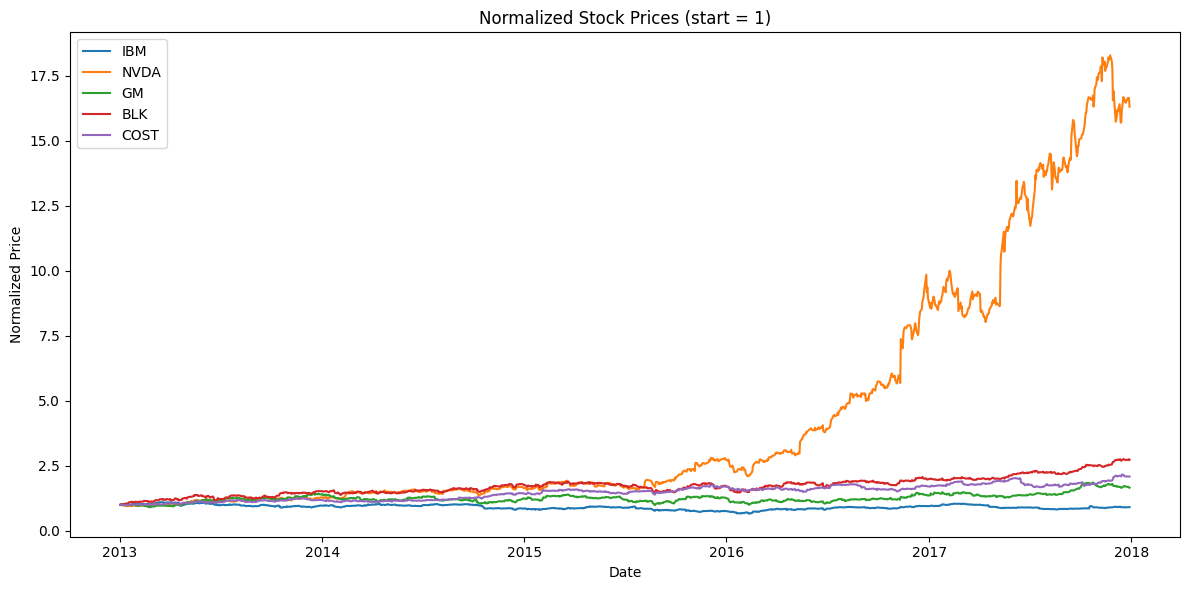

price_df_train: (756, 5), price_df_valid: (503, 5)
obs shape after reset: (61,)
obs shape in step: (61,)
obs shape in step: (61,)
obs shape in step: (61,)
obs shape in step: (61,)
obs shape in step: (61,)
MACD window: [0.0005278421772929587, 0.001527601977191928, 0.001509288961566435, 0.0008163030789165582, 0.0006231915088850126]
BB dev window: [0.0, 0.0, 0.0, 0.0, 0.0]
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 755      |
|    ep_rew_mean     | 49.8     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 422      |
|    time_elapsed    | 7        |
|    total_timesteps | 3020     |
| train/             |          |
|    actor_loss      | -3.06    |
|    critic_loss     | 0.0439   |
|    learning_rate   | 0.0003   |
|    n_updates       | 2919     |
---------------------------------
----------------------

In [ ]:
# Control The DDPG retrain
RUN_OPTIONAL_TRAINING = True

if RUN_OPTIONAL_TRAINING:
    price_df = load_price_data(config)
    plot_normalized_prices(price_df, config)

    splits = split_price_data(price_df, config)
    model = train_offline_model(splits.train, splits.valid, config)
else:
    print("Optional training skipped. Set RUN_OPTIONAL_TRAINING = True to retrain.")


## 4. Output notes

- Figure files:
  - `addenda/result_picture/online_reward_only_ddpg_2026-01-01_2026-06-21.png`
  - `addenda/result_picture/online_wealth_only_ddpg_2026-01-01_2026-06-21.png`
  - `addenda/result_picture/online_daily_return_only_ddpg_2026-01-01_2026-06-21.png`

- Profile file:
  - `addenda/result_profile_comparse/only_ddpg_online_profile_2026-01-01_2026-06-21.csv`

- Use this profile as the baseline when comparing against DDPG+SLM.


## Workflow Notes - Pure DDPG

- The main agent is a price-based DDPG policy.

- The training environment uses:
  - recent portfolio returns,
  - MACD-like wealth trend,
  - Bollinger-style wealth deviation,
  - normalized wealth.

- The online evaluation uses the same trained model.

- No language model is used in this pipeline.

- The goal is to understand the baseline behavior first:
  - Does wealth grow or shrink?
  - Is reward stable or noisy?
  - How large is the drawdown?

- After this notebook runs, run the SLM notebook and compare the two profile CSV files.
